# Notebook 34 — State-aware DC–AC waveform scheduling

## Goal

Use the Day33 plating-risk localization map to build and test a first rule-based state-aware DC–AC waveform schedule.

Notebook 34 does **not** implement full MPC, Bayesian optimization, or experimental closed-loop control. It creates a physics-informed scheduling baseline that can later become MPC/BO-ready.

Core question:

> Can a rule-based state-aware DC–AC schedule preserve the hard negative-electrode margin while retaining part of the raw timing gain of fixed DC–AC excitation?

## Scientific context

The project no longer optimizes for the fastest raw DC–AC protocol. The current target is an admissible fast protocol under multiple constraints:

1. state-equivalent timing gain,
2. geometry–residual separation,
3. microstate response,
4. negative-electrode plating margin,
5. future thermal / aging admissibility.

Prior findings:

- Notebook 30: raw timing gain is geometry-dominated; microstate response exists.
- Notebook 31: Chen2020 / DFN has a hard-margin boundary near AC≈0.386C at fixed 1.5τ_set.
- Notebook 32: timing geometry dominance transfers; plating-margin admissibility is parameter-set dependent.
- Notebook 33: plating-margin risk localizes near high-Q / voltage-boundary-adjacent operation and is phase-locked to the AC charge-current peak.

## Day34A — Rule-based scheduling baseline

Day34A tests a predefined schedule derived from Day33:

```text
early / mid Q: allow AC
high Q: derate AC
near end: turn AC off
```

Initial rule-based schedule:

```text
0.00 <= Q_ref_frac < 0.75: DC 0.3C + AC 0.38C
0.75 <= Q_ref_frac < 0.85: DC 0.3C + AC 0.20C
0.85 <= Q_ref_frac       : pure DC 0.3C
```

This is implemented as a time-scheduled approximation using the DC reference Q progression. It is not feedback control.

## Protocol comparison

Minimum protocol set:

- DC 0.3C reference
- Fixed DC–AC 0.3C + 0.38C at 1.5τ_set
- Fixed DC–AC 0.3C + 0.7C at 1.5τ_set stress case
- Scheduled DC–AC v1 using the above derating rule

## Interpretation boundary

- This notebook tests a rule-based scheduling baseline, not a globally optimized controller.
- The schedule is state-aware in design but pre-programmed in execution.
- U_NE vs Li/Li+ remains a thermodynamic plating-margin proxy; risk_flag is not confirmed lithium plating.
- The 50 mV threshold is an audit buffer, not a universal physical constant.
- Thermal admissibility remains deferred.

In [1]:
# Cell 1 — Imports, paths, and Day34 metadata（导入库、路径与Day34元数据）

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

warnings.filterwarnings("default")

REPO = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA_DIR = REPO / "data"
FIG_DIR = REPO / "figures"
DOCS_DIR = REPO / "docs"

for p in [DATA_DIR, FIG_DIR, DOCS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PRIMARY_PARAMETER_SET = "Chen2020"
MODEL_TYPE = "DFN"
FREQUENCY_MODE = "set_rebased"

DC_C = 0.3
TAU_FACTOR_MAIN = 1.5
TAU_REF_SET_S = 36.316532231592305
F_MAIN_HZ = 1.0 / (2.0 * np.pi * TAU_FACTOR_MAIN * TAU_REF_SET_S)
PERIOD_MAIN_S = 1.0 / F_MAIN_HZ

PLATING_MARGIN_SAFE_BUFFER_V = 0.050

DAY34_METADATA = {
    "notebook": "34_state_aware_dcac_waveform_scheduling.ipynb",
    "parameter_set": PRIMARY_PARAMETER_SET,
    "model_type": MODEL_TYPE,
    "frequency_mode": FREQUENCY_MODE,
    "tau_factor_main": TAU_FACTOR_MAIN,
    "tau_ref_set_s": TAU_REF_SET_S,
    "f_main_Hz": F_MAIN_HZ,
    "purpose": "rule-based state-aware DCAC scheduling baseline",
    "not_mpc_or_bo": True,
}

metadata_path = DATA_DIR / "day34_metadata.json"
metadata_path.write_text(json.dumps(DAY34_METADATA, indent=2), encoding="utf-8")

print("[OK] repo:", REPO)
print("[OK] pybamm version:", pybamm.__version__)
print("[OK] f_main_Hz:", F_MAIN_HZ)
print("[OK] period_main_s:", PERIOD_MAIN_S)
print("[OK] saved metadata:", metadata_path)

[OK] repo: /Users/louislu/pybamm-dcac-superimposed
[OK] pybamm version: 26.3.1
[OK] f_main_Hz: 0.002921625190367048
[OK] period_main_s: 342.27525258788194
[OK] saved metadata: /Users/louislu/pybamm-dcac-superimposed/data/day34_metadata.json


In [2]:
# Cell 2 — Load Day33 reference values and define schedule breakpoints（读取Day33参考值并定义调度断点）

day33b_run_path = DATA_DIR / "day33b_run_summary.csv"

if day33b_run_path.exists():
    day33b_run_df = pd.read_csv(day33b_run_path)
    dc_ref_rows = day33b_run_df[day33b_run_df["condition"] == "Chen2020_DFN_Day33B_DC03"]
    if len(dc_ref_rows) == 1:
        Q_REF_AH = float(dc_ref_rows["Q_end_Ah"].iloc[0])
    else:
        Q_REF_AH = 4.492879
else:
    Q_REF_AH = 4.492879

parameter_values_ref = pybamm.ParameterValues(PRIMARY_PARAMETER_SET)
Q_NOM_AH = float(parameter_values_ref["Nominal cell capacity [A.h]"])
I_DC_A = DC_C * Q_NOM_AH

Q_FRAC_DERATE = 0.75
Q_FRAC_AC_OFF = 0.85

# Pre-programmed schedule based on DC-reference Q progression.
T_DERATE_S = Q_FRAC_DERATE * Q_REF_AH * 3600.0 / I_DC_A
T_AC_OFF_S = Q_FRAC_AC_OFF * Q_REF_AH * 3600.0 / I_DC_A

print("[OK] Q_NOM_AH:", Q_NOM_AH)
print("[OK] Q_REF_AH:", Q_REF_AH)
print("[OK] I_DC_A:", I_DC_A)
print("[OK] T_DERATE_S:", T_DERATE_S, "=", T_DERATE_S / 60, "min")
print("[OK] T_AC_OFF_S:", T_AC_OFF_S, "=", T_AC_OFF_S / 60, "min")

[OK] Q_NOM_AH: 5.0
[OK] Q_REF_AH: 4.4928790028035
[OK] I_DC_A: 1.5
[OK] T_DERATE_S: 8087.182205046301 = 134.78637008410502 min
[OK] T_AC_OFF_S: 9165.473165719139 = 152.75788609531898 min


In [3]:
# Cell 3 — Define Day34 protocol schedule table（定义Day34协议调度表）

protocol_rows = [
    {
        "condition": "Chen2020_DFN_Day34_DC03",
        "protocol_type": "DC",
        "case_role": "dc_reference",
        "dc_c": DC_C,
        "schedule_type": "constant",
        "fixed_ac_c": 0.0,
        "early_ac_c": 0.0,
        "mid_ac_c": 0.0,
        "late_ac_c": 0.0,
        "peak_c_nominal": DC_C,
        "tau_factor_set": np.nan,
        "f_Hz": np.nan,
        "period_s": np.nan,
        "schedule_note": "pure DC reference",
    },
    {
        "condition": "Chen2020_DFN_Day34_fixed_AC0p38",
        "protocol_type": "DCAC",
        "case_role": "fixed_near_boundary_baseline",
        "dc_c": DC_C,
        "schedule_type": "constant",
        "fixed_ac_c": 0.38,
        "early_ac_c": 0.38,
        "mid_ac_c": 0.38,
        "late_ac_c": 0.38,
        "peak_c_nominal": DC_C + 0.38,
        "tau_factor_set": TAU_FACTOR_MAIN,
        "f_Hz": F_MAIN_HZ,
        "period_s": PERIOD_MAIN_S,
        "schedule_note": "fixed near-boundary amplitude from Day31-Day33",
    },
    {
        "condition": "Chen2020_DFN_Day34_fixed_AC0p7",
        "protocol_type": "DCAC",
        "case_role": "fixed_stress_baseline",
        "dc_c": DC_C,
        "schedule_type": "constant",
        "fixed_ac_c": 0.70,
        "early_ac_c": 0.70,
        "mid_ac_c": 0.70,
        "late_ac_c": 0.70,
        "peak_c_nominal": DC_C + 0.70,
        "tau_factor_set": TAU_FACTOR_MAIN,
        "f_Hz": F_MAIN_HZ,
        "period_s": PERIOD_MAIN_S,
        "schedule_note": "fixed high-amplitude stress case",
    },
    {
        "condition": "Chen2020_DFN_Day34_sched_Qfrac_v1",
        "protocol_type": "DCAC_SCHEDULED",
        "case_role": "rule_based_state_aware_v1",
        "dc_c": DC_C,
        "schedule_type": "qfrac_time_proxy",
        "fixed_ac_c": np.nan,
        "early_ac_c": 0.38,
        "mid_ac_c": 0.20,
        "late_ac_c": 0.00,
        "peak_c_nominal": DC_C + 0.38,
        "tau_factor_set": TAU_FACTOR_MAIN,
        "f_Hz": F_MAIN_HZ,
        "period_s": PERIOD_MAIN_S,
        "schedule_note": "0-75% Qref: AC0.38; 75-85% Qref: AC0.20; >85% Qref: AC off",
    },
]

protocol_df = pd.DataFrame(protocol_rows)

out = DATA_DIR / "day34_protocol_schedule_table.csv"
protocol_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(protocol_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day34_protocol_schedule_table.csv


,condition,protocol_type,case_role,dc_c,schedule_type,fixed_ac_c,early_ac_c,mid_ac_c,late_ac_c,peak_c_nominal,tau_factor_set,f_Hz,period_s,schedule_note
0,Chen2020_DFN_Day34_DC03,DC,dc_reference,0.3,constant,0.00,0.00,0.00,0.00,0.30,NaN,NaN,NaN,pure DC reference
1,Chen2020_DFN_Day34_fixed_AC0p38,DCAC,fixed_near_boundary_baseline,0.3,constant,0.38,0.38,0.38,0.38,0.68,1.5,0.002922,342.275253,fixed near-boundary amplitude from Day31-Day33
2,Chen2020_DFN_Day34_fixed_AC0p7,DCAC,fixed_stress_baseline,0.3,constant,0.70,0.70,0.70,0.70,1.00,1.5,0.002922,342.275253,fixed high-amplitude stress case
3,Chen2020_DFN_Day34_sched_Qfrac_v1,DCAC_SCHEDULED,rule_based_state_aware_v1,0.3,qfrac_time_proxy,NaN,0.38,0.20,0.00,0.68,1.5,0.002922,342.275253,0-75% Qref: AC0.38; 75-85% Qref: AC0.20; >85% ...


In [4]:
# Cell 4 — Current waveform and schedule utilities（电流波形与调度工具函数）

def ac_amplitude_c_at_time(t_s, protocol_row):
    stype = protocol_row["schedule_type"]
    t_s = np.asarray(t_s, dtype=float)

    if stype == "constant":
        return np.full_like(t_s, float(protocol_row["fixed_ac_c"]), dtype=float)

    if stype == "qfrac_time_proxy":
        ac = np.zeros_like(t_s, dtype=float)
        ac[t_s < T_DERATE_S] = float(protocol_row["early_ac_c"])
        ac[(t_s >= T_DERATE_S) & (t_s < T_AC_OFF_S)] = float(protocol_row["mid_ac_c"])
        ac[t_s >= T_AC_OFF_S] = float(protocol_row["late_ac_c"])
        return ac

    raise ValueError(f"Unknown schedule_type: {stype}")


def charge_current_A(t_s, protocol_row, q_nom_Ah=Q_NOM_AH):
    t_s = np.asarray(t_s, dtype=float)
    i_dc = float(protocol_row["dc_c"]) * q_nom_Ah
    ac_c = ac_amplitude_c_at_time(t_s, protocol_row)
    i_ac = ac_c * q_nom_Ah

    if pd.isna(protocol_row["f_Hz"]) or float(protocol_row["f_Hz"]) == 0:
        return i_dc + np.zeros_like(t_s)

    f_hz = float(protocol_row["f_Hz"])
    return i_dc + i_ac * np.sin(2.0 * np.pi * f_hz * t_s)


def cumulative_trapezoid_np(y, x):
    y = np.asarray(y, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    if len(y) != len(x):
        raise ValueError("x and y length mismatch")
    if len(y) < 2:
        return np.zeros_like(y)
    dx = np.diff(x)
    area = 0.5 * (y[:-1] + y[1:]) * dx
    return np.concatenate([[0.0], np.cumsum(area)])


def sample_protocol_waveform(protocol_row, t_max_s=12000, dt_s=0.5):
    t = np.arange(0.0, t_max_s + dt_s, dt_s)
    i_charge = charge_current_A(t, protocol_row)
    q_geom = cumulative_trapezoid_np(i_charge, t) / 3600.0
    ac_c = ac_amplitude_c_at_time(t, protocol_row)

    return pd.DataFrame({
        "t_s": t,
        "I_charge_A": i_charge,
        "I_py_A": -i_charge,
        "Q_geom_Ah": q_geom,
        "AC_C_scheduled": ac_c,
    })

print("[OK] waveform utilities ready")

[OK] waveform utilities ready


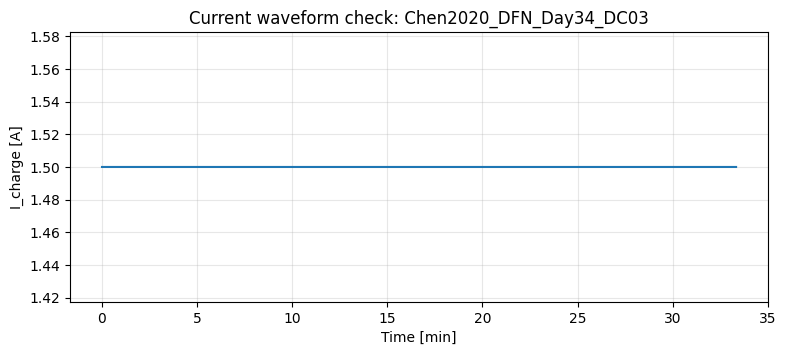

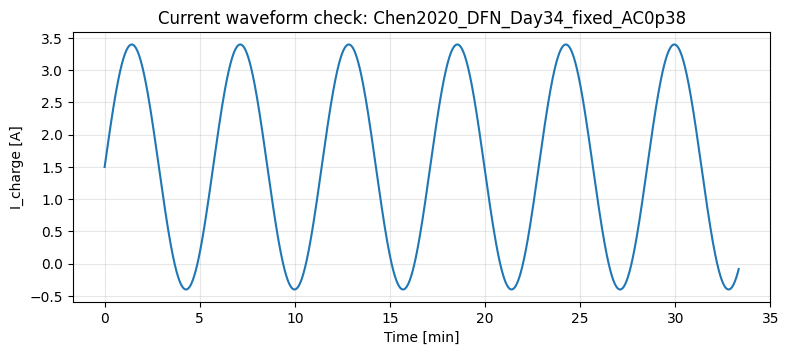

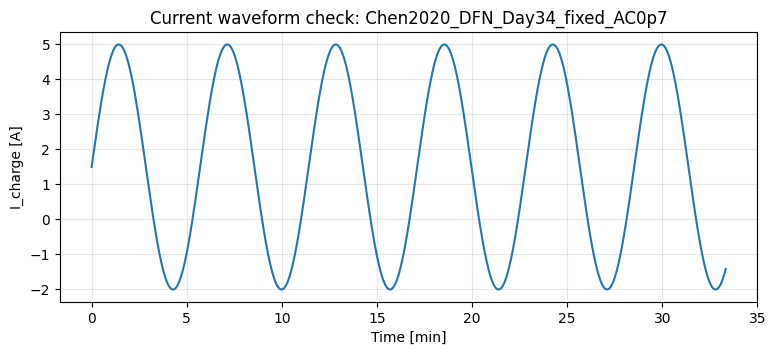

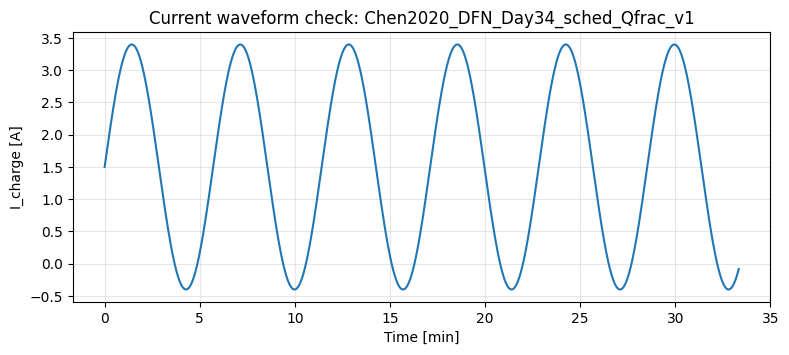

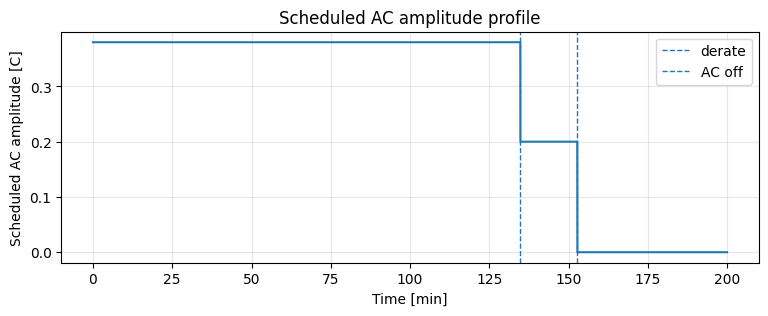

[OK] saved waveform audit: /Users/louislu/pybamm-dcac-superimposed/data/day34_current_waveform_audit.csv
[OK] saved waveform summary: /Users/louislu/pybamm-dcac-superimposed/data/day34_current_waveform_summary.csv


,condition,I_charge_min_A,I_charge_max_A,Q_geom_end_Ah,AC_C_min,AC_C_max
0,Chen2020_DFN_Day34_DC03,1.5,1.5,5.000000,0.00,0.00
1,Chen2020_DFN_Day34_fixed_AC0p38,-0.4,3.4,5.001986,0.38,0.38
2,Chen2020_DFN_Day34_fixed_AC0p7,-2.0,5.0,5.031072,0.70,0.70
3,Chen2020_DFN_Day34_sched_Qfrac_v1,-0.4,3.4,5.035608,0.00,0.38


In [5]:
# Cell 5 — Current waveform verification（电流波形验证）

waveform_records = []

for _, row in protocol_df.iterrows():
    wf = sample_protocol_waveform(row.to_dict(), t_max_s=12000, dt_s=0.5)
    wf["condition"] = row["condition"]
    waveform_records.append(wf)

    fig, ax = plt.subplots(figsize=(9, 3.5))
    mask = wf["t_s"] <= min(2000, wf["t_s"].max())
    ax.plot(wf.loc[mask, "t_s"] / 60, wf.loc[mask, "I_charge_A"])
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("I_charge [A]")
    ax.set_title(f"Current waveform check: {row['condition']}")
    ax.grid(True, alpha=0.3)
    plt.show()

    if row["condition"].endswith("sched_Qfrac_v1"):
        fig, ax = plt.subplots(figsize=(9, 3.0))
        ax.plot(wf["t_s"] / 60, wf["AC_C_scheduled"])
        ax.axvline(T_DERATE_S / 60, linestyle="--", linewidth=1, label="derate")
        ax.axvline(T_AC_OFF_S / 60, linestyle="--", linewidth=1, label="AC off")
        ax.set_xlabel("Time [min]")
        ax.set_ylabel("Scheduled AC amplitude [C]")
        ax.set_title("Scheduled AC amplitude profile")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()

waveform_audit_df = pd.concat(waveform_records, ignore_index=True)

out = DATA_DIR / "day34_current_waveform_audit.csv"
waveform_audit_df.to_csv(out, index=False)

summary_df = (
    waveform_audit_df
    .groupby("condition", as_index=False)
    .agg(
        I_charge_min_A=("I_charge_A", "min"),
        I_charge_max_A=("I_charge_A", "max"),
        Q_geom_end_Ah=("Q_geom_Ah", "max"),
        AC_C_min=("AC_C_scheduled", "min"),
        AC_C_max=("AC_C_scheduled", "max"),
    )
)

out_summary = DATA_DIR / "day34_current_waveform_summary.csv"
summary_df.to_csv(out_summary, index=False)

print("[OK] saved waveform audit:", out)
print("[OK] saved waveform summary:", out_summary)
display(summary_df)

In [6]:
# Cell 6 — PyBaMM simulation utilities for fixed and scheduled currents（固定与调度电流的PyBaMM仿真工具）

def make_model(model_type="DFN"):
    if model_type == "DFN":
        return pybamm.lithium_ion.DFN({"thermal": "isothermal"})
    if model_type == "SPMe":
        return pybamm.lithium_ion.SPMe({"thermal": "isothermal"})
    if model_type == "SPM":
        return pybamm.lithium_ion.SPM({"thermal": "isothermal"})
    raise ValueError(f"Unknown model_type: {model_type}")


def make_parameter_values_with_profile_current(protocol_row, max_time_s=24000, current_dt_s=1.0):
    """
    Use an interpolated prescribed-current profile for both fixed and scheduled waveforms.

    PyBaMM convention:
    +I = discharge
    -I = charge

    We define charge-positive current externally and pass I_py = -I_charge to PyBaMM.
    """
    pv = pybamm.ParameterValues(PRIMARY_PARAMETER_SET)
    q_nom_Ah = float(pv["Nominal cell capacity [A.h]"])

    t_grid = np.arange(0.0, max_time_s + current_dt_s, current_dt_s)
    i_charge_grid = charge_current_A(t_grid, protocol_row, q_nom_Ah=q_nom_Ah)
    i_py_grid = -i_charge_grid

    current_interpolant = pybamm.Interpolant(
        t_grid,
        i_py_grid,
        pybamm.t,
        interpolator="linear",
    )

    pv.update({"Current function [A]": current_interpolant}, check_already_exists=False)

    q_geom_grid = cumulative_trapezoid_np(i_charge_grid, t_grid) / 3600.0
    ac_c_grid = ac_amplitude_c_at_time(t_grid, protocol_row)

    geom_df = pd.DataFrame({
        "t_s": t_grid,
        "I_charge_A": i_charge_grid,
        "I_py_A": i_py_grid,
        "Q_geom_Ah": q_geom_grid,
        "AC_C_scheduled": ac_c_grid,
    })

    meta = {
        "nominal_capacity_Ah": q_nom_Ah,
        "max_time_s": max_time_s,
        "current_dt_s": current_dt_s,
        "phase_convention": "charge_first",
        "current_definition": "I_py(t) = -I_charge(t), interpolated prescribed profile",
    }

    return pv, geom_df, meta


def extract_basic_timeseries(sol):
    t_s = np.asarray(sol.t, dtype=float)
    I_py_A = np.asarray(sol["Current [A]"](t_s), dtype=float).reshape(-1)
    V_terminal_V = np.asarray(sol["Terminal voltage [V]"](t_s), dtype=float).reshape(-1)

    I_charge_A = -I_py_A
    Q_net_Ah = cumulative_trapezoid_np(I_charge_A, t_s) / 3600.0

    return pd.DataFrame({
        "t_s": t_s,
        "I_py_A": I_py_A,
        "I_charge_A": I_charge_A,
        "V_terminal_V": V_terminal_V,
        "Q_net_Ah": Q_net_Ah,
    })


def run_day34_simulation(protocol_row, initial_soc=0.05, max_time_s=24000, n_eval=5000, current_dt_s=1.0):
    model = make_model(MODEL_TYPE)
    pv, geom_df, meta = make_parameter_values_with_profile_current(
        protocol_row=protocol_row,
        max_time_s=max_time_s,
        current_dt_s=current_dt_s,
    )

    sim = pybamm.Simulation(model, parameter_values=pv)
    t_eval = np.linspace(0.0, max_time_s, n_eval)
    sol = sim.solve(t_eval=t_eval, initial_soc=initial_soc)
    ts = extract_basic_timeseries(sol)

    return sim, sol, ts, geom_df, meta

print("[OK] Day34 simulation utilities ready")

[OK] Day34 simulation utilities ready


In [7]:
# Cell 7 — Run Day34 protocol simulations（运行Day34协议仿真）

solutions = {}
run_rows = []

for _, row in protocol_df.iterrows():
    cond = row["condition"]
    print(f"\n[RUN] {cond}")

    try:
        sim_i, sol_i, ts_i, geom_i, meta_i = run_day34_simulation(row.to_dict())

        solutions[cond] = {
            "sim": sim_i,
            "sol": sol_i,
            "ts": ts_i,
            "geom": geom_i,
            "meta": meta_i,
            "protocol": row.to_dict(),
        }

        run_rows.append({
            "condition": cond,
            "case_role": row["case_role"],
            "status": "ok",
            "termination": str(sol_i.termination),
            "t_end_s": float(ts_i["t_s"].iloc[-1]),
            "t_end_min": float(ts_i["t_s"].iloc[-1] / 60.0),
            "Q_end_Ah": float(ts_i["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts_i["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts_i["I_charge_A"].min()),
            "I_charge_max_A": float(ts_i["I_charge_A"].max()),
            "AC_C_min": float(geom_i["AC_C_scheduled"].min()),
            "AC_C_max": float(geom_i["AC_C_scheduled"].max()),
            "error": "",
        })

        print("[OK]", cond, "| termination:", sol_i.termination)

    except Exception as e:
        run_rows.append({
            "condition": cond,
            "case_role": row["case_role"],
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "AC_C_min": np.nan,
            "AC_C_max": np.nan,
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

run_summary_df = pd.DataFrame(run_rows)

out = DATA_DIR / "day34_run_summary.csv"
run_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(run_summary_df)


[RUN] Chen2020_DFN_Day34_DC03
[OK] Chen2020_DFN_Day34_DC03 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day34_fixed_AC0p38
[OK] Chen2020_DFN_Day34_fixed_AC0p38 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day34_fixed_AC0p7
[OK] Chen2020_DFN_Day34_fixed_AC0p7 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day34_sched_Qfrac_v1
[OK] Chen2020_DFN_Day34_sched_Qfrac_v1 | termination: event: Maximum voltage [V]
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day34_run_summary.csv


,condition,case_role,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,AC_C_min,AC_C_max,error
0,Chen2020_DFN_Day34_DC03,dc_reference,ok,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000,1.500000,0.00,0.00,
1,Chen2020_DFN_Day34_fixed_AC0p38,fixed_near_boundary_baseline,ok,event: Maximum voltage [V],9318.002845,155.300047,3.906509,4.2,-0.399987,3.399991,0.38,0.38,
2,Chen2020_DFN_Day34_fixed_AC0p7,fixed_stress_baseline,ok,event: Maximum voltage [V],8627.927468,143.798791,3.633945,4.2,-1.999972,4.999984,0.70,0.70,
3,Chen2020_DFN_Day34_sched_Qfrac_v1,rule_based_state_aware_v1,ok,event: Maximum voltage [V],10696.821273,178.280355,4.492489,4.2,-0.399987,3.399991,0.00,0.38,


In [8]:
# Cell 8 — Extract plating-margin and microstate context（提取析锂余量与微观状态背景）

NE_SURFACE_KEY = "Negative electrode surface potential difference [V]"
NE_SEPARATOR_KEY = "Negative electrode surface potential difference at separator interface [V]"
NE_XAVG_KEY = "X-averaged negative electrode surface potential difference [V]"
ELYTE_C_KEY = "Electrolyte concentration [mol.m-3]"
ETA_N_KEY = "X-averaged negative electrode reaction overpotential [V]"
ETA_P_KEY = "X-averaged positive electrode reaction overpotential [V]"
NEG_SURF_STO_XAVG_KEY = "X-averaged negative particle surface stoichiometry"
NEG_SURF_STO_MAX_KEY = "Maximum negative particle surface stoichiometry"
NEG_SURF_STO_MIN_KEY = "Minimum negative particle surface stoichiometry"


def reduce_to_timeseries(arr, t_s, reducer="mean"):
    arr = np.asarray(arr, dtype=float)
    t_s = np.asarray(t_s, dtype=float)
    n_t = len(t_s)

    if arr.ndim == 0:
        return np.full(n_t, float(arr))
    if arr.ndim == 1:
        if arr.shape[0] == n_t:
            return arr
        return np.full(n_t, np.nanmean(arr))

    if arr.shape[-1] == n_t:
        flat = arr.reshape(-1, n_t)
        axis = 0
    elif arr.shape[0] == n_t:
        flat = arr.reshape(n_t, -1)
        axis = 1
    else:
        raise ValueError(f"Cannot identify time axis: arr.shape={arr.shape}, n_t={n_t}")

    if reducer == "min":
        return np.nanmin(flat, axis=axis)
    if reducer == "max":
        return np.nanmax(flat, axis=axis)
    if reducer == "mean":
        return np.nanmean(flat, axis=axis)
    raise ValueError(reducer)


def safe_extract(sol, key, t_s, reducer="mean"):
    try:
        return reduce_to_timeseries(sol[key](t_s), t_s, reducer=reducer)
    except Exception as e:
        print(f"[WARN] failed to extract {key}: {repr(e)}")
        return np.full(len(t_s), np.nan)


def classify_margin(u_v):
    if pd.isna(u_v):
        return "unresolved"
    if u_v <= 0.0:
        return "risk_flag"
    if u_v <= PLATING_MARGIN_SAFE_BUFFER_V:
        return "near_boundary"
    return "safe_margin"


def extract_day34_state_timeseries(obj):
    sol = obj["sol"]
    ts = obj["ts"].copy()
    t_s = ts["t_s"].to_numpy()

    ne_surface = sol[NE_SURFACE_KEY](t_s)
    ts["U_NE_min_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="min")
    ts["U_NE_mean_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="mean")
    ts["U_NE_separator_V"] = safe_extract(sol, NE_SEPARATOR_KEY, t_s, reducer="mean")
    ts["U_NE_xavg_V"] = safe_extract(sol, NE_XAVG_KEY, t_s, reducer="mean")
    ts["U_NE_min_mV"] = ts["U_NE_min_V"] * 1000.0
    ts["margin_class_inst"] = ts["U_NE_min_V"].apply(classify_margin)

    c_e = sol[ELYTE_C_KEY](t_s)
    ts["c_e_min_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="min")
    ts["c_e_max_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="max")
    ts["c_e_mean_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="mean")
    ts["c_e_range_molm3"] = ts["c_e_max_molm3"] - ts["c_e_min_molm3"]

    ts["eta_n_V"] = safe_extract(sol, ETA_N_KEY, t_s, reducer="mean")
    ts["eta_p_V"] = safe_extract(sol, ETA_P_KEY, t_s, reducer="mean")

    ts["neg_surface_sto_xavg"] = safe_extract(sol, NEG_SURF_STO_XAVG_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_max"] = safe_extract(sol, NEG_SURF_STO_MAX_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_min"] = safe_extract(sol, NEG_SURF_STO_MIN_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_range"] = ts["neg_surface_sto_max"] - ts["neg_surface_sto_min"]

    return ts


state_ts_map = {}
extract_rows = []

for cond, obj in solutions.items():
    print("[EXTRACT]", cond)
    ts = extract_day34_state_timeseries(obj)
    state_ts_map[cond] = ts

    extract_rows.append({
        "condition": cond,
        "n_time": len(ts),
        "min_U_NE_mV": float(ts["U_NE_min_mV"].min()),
        "fraction_time_below_50mV": float((ts["U_NE_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_min_V"] <= 0.0).mean()),
        "max_c_e_range_molm3": float(ts["c_e_range_molm3"].max()),
        "max_neg_surface_sto_range": float(np.nanmax(ts["neg_surface_sto_range"])),
        "status": "ok",
    })

extract_audit_df = pd.DataFrame(extract_rows)

out = DATA_DIR / "day34_state_extraction_audit.csv"
extract_audit_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(extract_audit_df)

[EXTRACT] Chen2020_DFN_Day34_DC03
[EXTRACT] Chen2020_DFN_Day34_fixed_AC0p38
[EXTRACT] Chen2020_DFN_Day34_fixed_AC0p7
[EXTRACT] Chen2020_DFN_Day34_sched_Qfrac_v1
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day34_state_extraction_audit.csv


,condition,n_time,min_U_NE_mV,fraction_time_below_50mV,fraction_time_below_0mV,max_c_e_range_molm3,max_neg_surface_sto_range,status
0,Chen2020_DFN_Day34_DC03,12159,37.280562,0.219837,0.000000,377.868423,0.116717,ok
1,Chen2020_DFN_Day34_fixed_AC0p38,14711,0.565686,0.143702,0.000000,747.684843,0.133279,ok
2,Chen2020_DFN_Day34_fixed_AC0p7,15500,-25.308203,0.220194,0.039484,1054.089062,0.173020,ok
3,Chen2020_DFN_Day34_sched_Qfrac_v1,15902,7.750469,0.223179,0.000000,747.684843,0.133279,ok


In [9]:
# Cell 9 — Protocol-level plating-margin and trigger summary（协议级析锂余量与触发摘要）

def compute_phase_norm(t_s, f_hz):
    if f_hz is None or pd.isna(f_hz):
        return np.nan
    phase = (2.0 * np.pi * f_hz * t_s) % (2.0 * np.pi)
    return phase / (2.0 * np.pi)


risk_rows = []

dc_condition = "Chen2020_DFN_Day34_DC03"
dc_Q_end_Ah = float(state_ts_map[dc_condition]["Q_net_Ah"].max())

for _, pr in protocol_df.iterrows():
    cond = pr["condition"]
    ts = state_ts_map[cond]
    obj = solutions[cond]

    idx_min = int(ts["U_NE_min_V"].idxmin())
    r = ts.loc[idx_min]

    f_hz = None if pd.isna(pr["f_Hz"]) else float(pr["f_Hz"])
    phase_norm = compute_phase_norm(float(r["t_s"]), f_hz)

    risk_rows.append({
        "condition": cond,
        "case_role": pr["case_role"],
        "protocol_type": pr["protocol_type"],
        "schedule_type": pr["schedule_type"],
        "min_U_NE_mV": float(r["U_NE_min_mV"]),
        "margin_class": classify_margin(float(r["U_NE_min_V"])),
        "fraction_time_below_50mV": float((ts["U_NE_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_min_V"] <= 0.0).mean()),
        "Q_end_Ah": float(ts["Q_net_Ah"].max()),
        "Q_at_min_U_NE_Ah": float(r["Q_net_Ah"]),
        "Q_frac_of_DC_end_at_min_U_NE": float(r["Q_net_Ah"] / dc_Q_end_Ah),
        "t_at_min_U_NE_s": float(r["t_s"]),
        "phase_norm_at_min_U_NE": phase_norm,
        "I_charge_at_min_U_NE_A": float(r["I_charge_A"]),
        "I_charge_peak_observed_A": float(ts["I_charge_A"].max()),
        "V_terminal_at_min_U_NE_V": float(r["V_terminal_V"]),
        "distance_to_4p2V_at_min_U_NE_mV": float((4.2 - r["V_terminal_V"]) * 1000.0),
        "c_e_range_at_min_U_NE_molm3": float(r["c_e_range_molm3"]),
        "max_c_e_range_molm3": float(ts["c_e_range_molm3"].max()),
        "neg_surface_sto_range_at_min_U_NE": float(r["neg_surface_sto_range"]),
        "eta_n_at_min_U_NE_V": float(r["eta_n_V"]) if np.isfinite(r["eta_n_V"]) else np.nan,
    })

risk_summary_df = pd.DataFrame(risk_rows)

out = DATA_DIR / "day34_protocol_margin_trigger_summary.csv"
risk_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(risk_summary_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day34_protocol_margin_trigger_summary.csv


,condition,case_role,protocol_type,schedule_type,min_U_NE_mV,margin_class,fraction_time_below_50mV,fraction_time_below_0mV,Q_end_Ah,Q_at_min_U_NE_Ah,...,t_at_min_U_NE_s,phase_norm_at_min_U_NE,I_charge_at_min_U_NE_A,I_charge_peak_observed_A,V_terminal_at_min_U_NE_V,distance_to_4p2V_at_min_U_NE_mV,c_e_range_at_min_U_NE_molm3,max_c_e_range_molm3,neg_surface_sto_range_at_min_U_NE,eta_n_at_min_U_NE_V
0,Chen2020_DFN_Day34_DC03,dc_reference,DC,constant,37.280562,near_boundary,0.219837,0.000000,4.492879,4.492879,...,10782.909607,NaN,1.500000,1.500000,4.200000,0.000000e+00,354.118549,377.868423,0.116717,-0.045310
1,Chen2020_DFN_Day34_fixed_AC0p38,fixed_near_boundary_baseline,DCAC,constant,0.565686,near_boundary,0.143702,0.000000,3.906509,3.906509,...,9318.002845,0.223712,3.374140,3.399991,4.200000,-4.973799e-11,623.732719,747.684843,0.126834,-0.073212
2,Chen2020_DFN_Day34_fixed_AC0p7,fixed_stress_baseline,DCAC,constant,-25.308203,risk_flag,0.220194,0.039484,3.633945,3.523653,...,8309.073455,0.275998,4.953367,4.999984,4.194776,5.223883e+00,961.394009,1054.089062,0.133266,-0.091417
3,Chen2020_DFN_Day34_sched_Qfrac_v1,rule_based_state_aware_v1,DCAC_SCHEDULED,qfrac_time_proxy,7.750469,near_boundary,0.223179,0.000000,4.492489,3.352470,...,7966.328807,0.274627,3.377230,3.399991,4.106146,9.385389e+01,693.577658,747.684843,0.084960,-0.069521


In [10]:
# Cell 10 — Equal-Q timing and geometry-residual comparison（等Q时间与几何-残差比较）

def first_passage_time(t_s, q_Ah, q_target_Ah):
    t_s = np.asarray(t_s, dtype=float)
    q_Ah = np.asarray(q_Ah, dtype=float)
    hit = np.where(q_Ah >= q_target_Ah)[0]
    if len(hit) == 0:
        return np.nan
    i = int(hit[0])
    if i == 0:
        return float(t_s[0])
    q0, q1 = q_Ah[i - 1], q_Ah[i]
    t0, t1 = t_s[i - 1], t_s[i]
    if q1 == q0:
        return float(t1)
    frac = (q_target_Ah - q0) / (q1 - q0)
    return float(t0 + frac * (t1 - t0))


def first_passage_from_geom_df(geom_df, q_target_Ah):
    return first_passage_time(
        geom_df["t_s"].to_numpy(),
        geom_df["Q_geom_Ah"].to_numpy(),
        q_target_Ah,
    )


dc_ts = state_ts_map[dc_condition]
dc_geom = solutions[dc_condition]["geom"]

q_end_all = min(float(ts["Q_net_Ah"].max()) for ts in state_ts_map.values())
q_grid = np.linspace(0.2, 0.95 * q_end_all, 100)

eq_rows = []

for _, pr in protocol_df.iterrows():
    cond = pr["condition"]
    if cond == dc_condition:
        continue

    ts = state_ts_map[cond]
    geom = solutions[cond]["geom"]

    for q in q_grid:
        t_dc = first_passage_time(dc_ts["t_s"], dc_ts["Q_net_Ah"], q)
        t_pr = first_passage_time(ts["t_s"], ts["Q_net_Ah"], q)

        t_dc_geom = first_passage_from_geom_df(dc_geom, q)
        t_pr_geom = first_passage_from_geom_df(geom, q)

        eq_rows.append({
            "condition": cond,
            "case_role": pr["case_role"],
            "Q_Ah": float(q),
            "t_DC_s": t_dc,
            "t_protocol_s": t_pr,
            "delta_t_raw_s": t_dc - t_pr,
            "t_DC_geom_s": t_dc_geom,
            "t_protocol_geom_s": t_pr_geom,
            "delta_t_geom_s": t_dc_geom - t_pr_geom,
            "delta_t_resid_s": (t_dc - t_pr) - (t_dc_geom - t_pr_geom),
        })

equalq_df = pd.DataFrame(eq_rows)

out = DATA_DIR / "day34_equalQ_timing_geom_resid_curves.csv"
equalq_df.to_csv(out, index=False)

summary_dt_df = (
    equalq_df
    .groupby(["condition", "case_role"], as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
        delta_t_geom_mean_s=("delta_t_geom_s", "mean"),
        delta_t_resid_mean_s=("delta_t_resid_s", "mean"),
        resid_abs_mean_s=("delta_t_resid_s", lambda x: np.nanmean(np.abs(x))),
        resid_max_abs_s=("delta_t_resid_s", lambda x: np.nanmax(np.abs(x))),
    )
)

def classify_resid(row):
    raw = abs(row["delta_t_raw_mean_s"])
    if raw < 1:
        return "near_zero_or_unresolved"
    ratio = row["resid_abs_mean_s"] / raw
    if ratio < 0.05:
        return "geometry_dominated"
    if ratio < 0.20:
        return "mostly_geometry_small_residual"
    return "residual_non_negligible"

summary_dt_df["dt_resid_class"] = summary_dt_df.apply(classify_resid, axis=1)

out_summary = DATA_DIR / "day34_equalQ_timing_geom_resid_summary.csv"
summary_dt_df.to_csv(out_summary, index=False)

print("[OK] saved equal-Q curves:", out)
print("[OK] saved timing summary:", out_summary)
display(summary_dt_df)

[OK] saved equal-Q curves: /Users/louislu/pybamm-dcac-superimposed/data/day34_equalQ_timing_geom_resid_curves.csv
[OK] saved timing summary: /Users/louislu/pybamm-dcac-superimposed/data/day34_equalQ_timing_geom_resid_summary.csv


,condition,case_role,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s,delta_t_geom_mean_s,delta_t_resid_mean_s,resid_abs_mean_s,resid_max_abs_s,dt_resid_class
0,Chen2020_DFN_Day34_fixed_AC0p38,fixed_near_boundary_baseline,69.350655,-0.012173,137.953460,69.363536,-0.012881,0.012948,0.045133,geometry_dominated
1,Chen2020_DFN_Day34_fixed_AC0p7,fixed_stress_baseline,158.665349,48.438917,254.159325,158.685568,-0.020219,0.020219,0.070742,geometry_dominated
2,Chen2020_DFN_Day34_sched_Qfrac_v1,rule_based_state_aware_v1,70.808641,-0.012173,137.953460,70.822051,-0.013410,0.013478,0.077131,geometry_dominated


In [11]:
# Cell 11 — Final Day34A scheduling ledger（Day34A调度结果账本）

ledger_df = (
    summary_dt_df
    .merge(
        risk_summary_df[
            [
                "condition",
                "case_role",
                "min_U_NE_mV",
                "margin_class",
                "fraction_time_below_50mV",
                "fraction_time_below_0mV",
                "Q_at_min_U_NE_Ah",
                "Q_frac_of_DC_end_at_min_U_NE",
                "I_charge_at_min_U_NE_A",
                "I_charge_peak_observed_A",
                "V_terminal_at_min_U_NE_V",
                "distance_to_4p2V_at_min_U_NE_mV",
                "c_e_range_at_min_U_NE_molm3",
                "eta_n_at_min_U_NE_V",
            ]
        ],
        on=["condition", "case_role"],
        how="left",
    )
)

def classify_schedule_verdict(row):
    if row["margin_class"] == "risk_flag":
        return "not_admissible_hard_margin"
    if row["margin_class"] == "near_boundary":
        if row["delta_t_raw_mean_s"] > 10:
            return "admissible_near_boundary_with_raw_gain"
        return "near_boundary_low_gain"
    if row["margin_class"] == "safe_margin":
        if row["delta_t_raw_mean_s"] > 10:
            return "safe_margin_with_raw_gain"
        return "safe_margin_low_gain"
    return "unresolved"

ledger_df["schedule_verdict"] = ledger_df.apply(classify_schedule_verdict, axis=1)

out = DATA_DIR / "day34_state_aware_scheduling_ledger.csv"
ledger_df.to_csv(out, index=False)

print("[OK] saved Day34 scheduling ledger:", out)

cols = [
    "condition",
    "case_role",
    "delta_t_raw_mean_s",
    "delta_t_geom_mean_s",
    "delta_t_resid_mean_s",
    "resid_abs_mean_s",
    "dt_resid_class",
    "min_U_NE_mV",
    "margin_class",
    "fraction_time_below_50mV",
    "fraction_time_below_0mV",
    "Q_frac_of_DC_end_at_min_U_NE",
    "I_charge_at_min_U_NE_A",
    "I_charge_peak_observed_A",
    "schedule_verdict",
]

display(ledger_df[cols])

[OK] saved Day34 scheduling ledger: /Users/louislu/pybamm-dcac-superimposed/data/day34_state_aware_scheduling_ledger.csv


,condition,case_role,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,resid_abs_mean_s,dt_resid_class,min_U_NE_mV,margin_class,fraction_time_below_50mV,fraction_time_below_0mV,Q_frac_of_DC_end_at_min_U_NE,I_charge_at_min_U_NE_A,I_charge_peak_observed_A,schedule_verdict
0,Chen2020_DFN_Day34_fixed_AC0p38,fixed_near_boundary_baseline,69.350655,69.363536,-0.012881,0.012948,geometry_dominated,0.565686,near_boundary,0.143702,0.000000,0.869489,3.374140,3.399991,admissible_near_boundary_with_raw_gain
1,Chen2020_DFN_Day34_fixed_AC0p7,fixed_stress_baseline,158.665349,158.685568,-0.020219,0.020219,geometry_dominated,-25.308203,risk_flag,0.220194,0.039484,0.784275,4.953367,4.999984,not_admissible_hard_margin
2,Chen2020_DFN_Day34_sched_Qfrac_v1,rule_based_state_aware_v1,70.808641,70.822051,-0.013410,0.013478,geometry_dominated,7.750469,near_boundary,0.223179,0.000000,0.746174,3.377230,3.399991,admissible_near_boundary_with_raw_gain


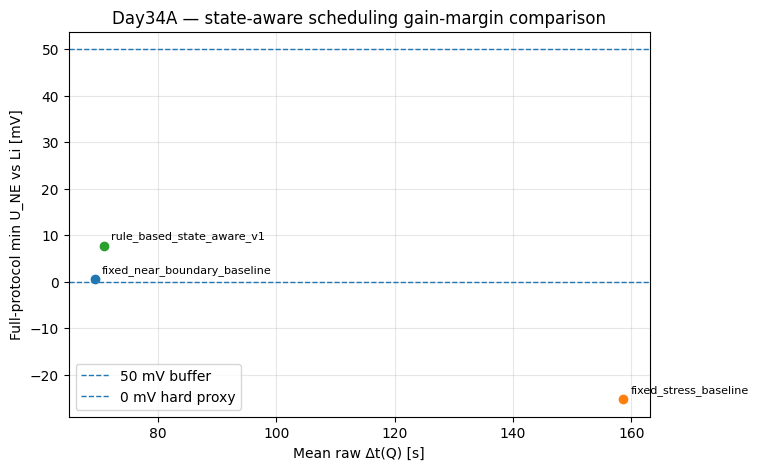

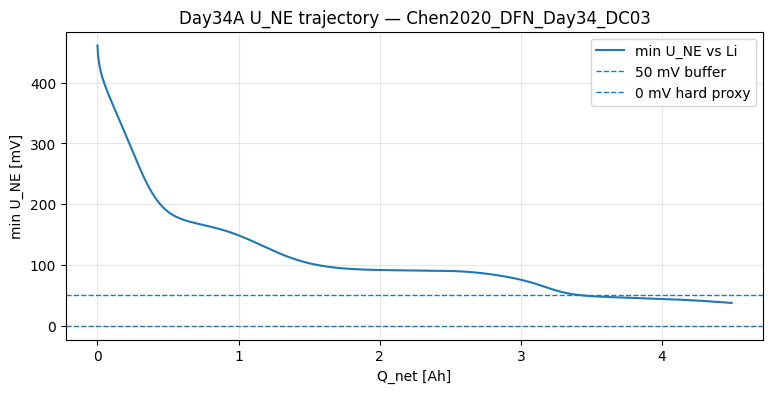

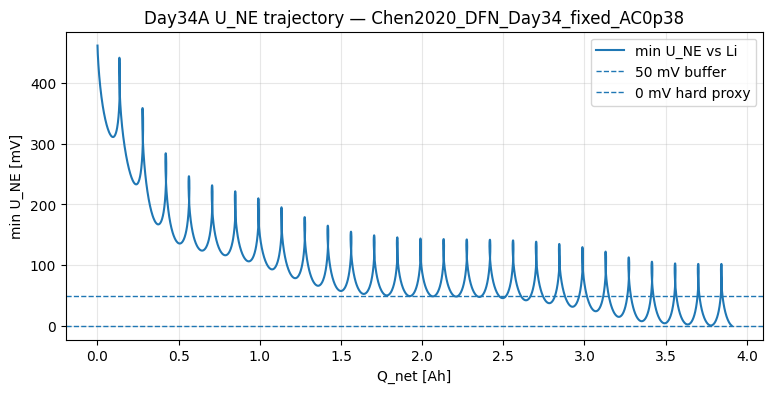

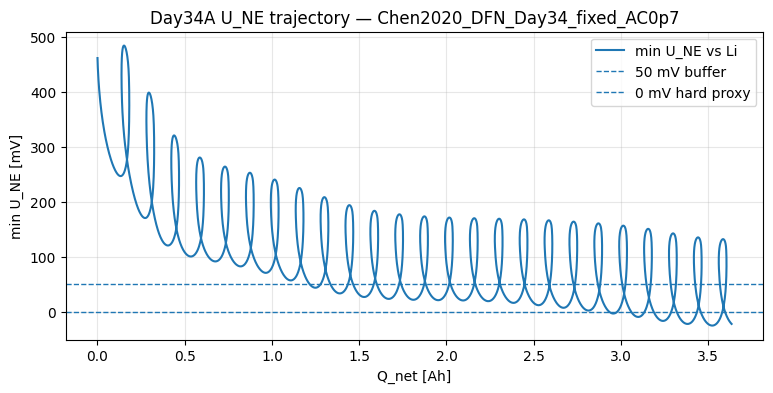

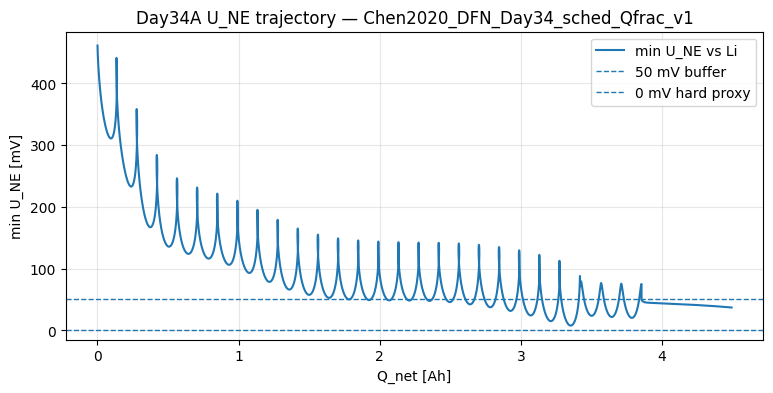

In [12]:
# Cell 12 — Plot Day34 gain-margin comparison（绘制Day34收益-余量比较）

plot_df = ledger_df.copy()

fig, ax = plt.subplots(figsize=(7.5, 5))
for _, row in plot_df.iterrows():
    ax.scatter(row["delta_t_raw_mean_s"], row["min_U_NE_mV"])
    ax.annotate(
        row["case_role"],
        (row["delta_t_raw_mean_s"], row["min_U_NE_mV"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )

ax.axhline(50, linestyle="--", linewidth=1, label="50 mV buffer")
ax.axhline(0, linestyle="--", linewidth=1, label="0 mV hard proxy")
ax.set_xlabel("Mean raw Δt(Q) [s]")
ax.set_ylabel("Full-protocol min U_NE vs Li [mV]")
ax.set_title("Day34A — state-aware scheduling gain-margin comparison")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

for cond, ts in state_ts_map.items():
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ts["Q_net_Ah"], ts["U_NE_min_mV"], label="min U_NE vs Li")
    ax.axhline(50, linestyle="--", linewidth=1, label="50 mV buffer")
    ax.axhline(0, linestyle="--", linewidth=1, label="0 mV hard proxy")
    ax.set_xlabel("Q_net [Ah]")
    ax.set_ylabel("min U_NE [mV]")
    ax.set_title(f"Day34A U_NE trajectory — {cond}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

In [13]:
# Cell 13 — Microstate stress comparison for scheduled DC–AC（调度DC–AC的微观状态压力对比）

micro_rows = []

dc_condition = "Chen2020_DFN_Day34_DC03"
dc_ts = state_ts_map[dc_condition]

dc_max_c_e_range = float(dc_ts["c_e_range_molm3"].max())
dc_max_surface_range = float(np.nanmax(dc_ts["neg_surface_sto_range"]))
dc_eta_n_min_point = float(
    risk_summary_df.loc[
        risk_summary_df["condition"] == dc_condition,
        "eta_n_at_min_U_NE_V"
    ].iloc[0]
)

for _, pr in protocol_df.iterrows():
    cond = pr["condition"]
    ts = state_ts_map[cond]
    
    risk_row = risk_summary_df[risk_summary_df["condition"] == cond].iloc[0]
    
    max_c_e_range = float(ts["c_e_range_molm3"].max())
    mean_c_e_range = float(ts["c_e_range_molm3"].mean())
    max_surface_range = float(np.nanmax(ts["neg_surface_sto_range"]))
    mean_surface_range = float(np.nanmean(ts["neg_surface_sto_range"]))
    
    micro_rows.append({
        "condition": cond,
        "case_role": pr["case_role"],
        "protocol_type": pr["protocol_type"],
        "schedule_type": pr["schedule_type"],
        "min_U_NE_mV": float(risk_row["min_U_NE_mV"]),
        "margin_class": risk_row["margin_class"],
        "Q_frac_of_DC_end_at_min_U_NE": float(risk_row["Q_frac_of_DC_end_at_min_U_NE"]),
        "I_charge_at_min_U_NE_A": float(risk_row["I_charge_at_min_U_NE_A"]),
        "V_terminal_at_min_U_NE_V": float(risk_row["V_terminal_at_min_U_NE_V"]),
        "c_e_range_at_min_U_NE_molm3": float(risk_row["c_e_range_at_min_U_NE_molm3"]),
        "max_c_e_range_molm3": max_c_e_range,
        "mean_c_e_range_molm3": mean_c_e_range,
        "c_e_range_at_min_vs_DC": float(risk_row["c_e_range_at_min_U_NE_molm3"]) / dc_max_c_e_range,
        "max_c_e_range_vs_DC": max_c_e_range / dc_max_c_e_range,
        "neg_surface_sto_range_at_min_U_NE": float(risk_row["neg_surface_sto_range_at_min_U_NE"]),
        "max_neg_surface_sto_range": max_surface_range,
        "mean_neg_surface_sto_range": mean_surface_range,
        "surface_range_at_min_vs_DC": float(risk_row["neg_surface_sto_range_at_min_U_NE"]) / dc_max_surface_range,
        "max_surface_range_vs_DC": max_surface_range / dc_max_surface_range,
        "eta_n_at_min_U_NE_V": float(risk_row["eta_n_at_min_U_NE_V"]),
        "eta_n_at_min_vs_DC": float(risk_row["eta_n_at_min_U_NE_V"]) / dc_eta_n_min_point,
    })

microstate_stress_df = pd.DataFrame(micro_rows)


def classify_microstate_context(row):
    """
    Conservative qualitative label.
    This is explanatory context, not an admissibility criterion.
    """
    if row["protocol_type"] == "DC":
        return "dc_reference_context"
    
    high_transport = row["max_c_e_range_vs_DC"] >= 1.5
    high_surface = row["max_surface_range_vs_DC"] >= 1.05
    near_or_risk_margin = row["margin_class"] in ["near_boundary", "risk_flag"]
    
    if high_transport and high_surface and near_or_risk_margin:
        return "transport_surface_stress_with_margin_pressure"
    if high_transport and near_or_risk_margin:
        return "transport_stress_with_margin_pressure"
    if high_surface and near_or_risk_margin:
        return "surface_stress_with_margin_pressure"
    if near_or_risk_margin:
        return "margin_pressure_without_large_microstate_amplification"
    return "low_microstate_stress_context"


microstate_stress_df["microstate_context_class"] = microstate_stress_df.apply(
    classify_microstate_context,
    axis=1,
)

out = DATA_DIR / "day34_microstate_stress_comparison.csv"
microstate_stress_df.to_csv(out, index=False)

print("[OK] saved microstate stress comparison:", out)

display_cols = [
    "condition",
    "case_role",
    "min_U_NE_mV",
    "margin_class",
    "max_c_e_range_molm3",
    "max_c_e_range_vs_DC",
    "c_e_range_at_min_U_NE_molm3",
    "c_e_range_at_min_vs_DC",
    "max_neg_surface_sto_range",
    "max_surface_range_vs_DC",
    "neg_surface_sto_range_at_min_U_NE",
    "surface_range_at_min_vs_DC",
    "eta_n_at_min_U_NE_V",
    "eta_n_at_min_vs_DC",
    "microstate_context_class",
]

display(microstate_stress_df[display_cols])


# Merge microstate context into the Day34 scheduling ledger.
ledger_with_microstate_df = ledger_df.merge(
    microstate_stress_df[
        [
            "condition",
            "max_c_e_range_molm3",
            "max_c_e_range_vs_DC",
            "c_e_range_at_min_U_NE_molm3",
            "c_e_range_at_min_vs_DC",
            "max_neg_surface_sto_range",
            "max_surface_range_vs_DC",
            "neg_surface_sto_range_at_min_U_NE",
            "surface_range_at_min_vs_DC",
            "eta_n_at_min_U_NE_V",
            "eta_n_at_min_vs_DC",
            "microstate_context_class",
        ]
    ],
    on="condition",
    how="left",
)

out = DATA_DIR / "day34_scheduling_ledger_with_microstate.csv"
ledger_with_microstate_df.to_csv(out, index=False)

print("[OK] saved scheduling ledger with microstate context:", out)

display_cols = [
    "condition",
    "case_role",
    "delta_t_raw_mean_s",
    "dt_resid_class",
    "min_U_NE_mV",
    "margin_class",
    "fraction_time_below_0mV",
    "max_c_e_range_vs_DC",
    "surface_range_at_min_vs_DC",
    "eta_n_at_min_vs_DC",
    "schedule_verdict",
    "microstate_context_class",
]

display(ledger_with_microstate_df[display_cols])

[OK] saved microstate stress comparison: /Users/louislu/pybamm-dcac-superimposed/data/day34_microstate_stress_comparison.csv


,condition,case_role,min_U_NE_mV,margin_class,max_c_e_range_molm3,max_c_e_range_vs_DC,c_e_range_at_min_U_NE_molm3,c_e_range_at_min_vs_DC,max_neg_surface_sto_range,max_surface_range_vs_DC,neg_surface_sto_range_at_min_U_NE,surface_range_at_min_vs_DC,eta_n_at_min_U_NE_V,eta_n_at_min_vs_DC,microstate_context_class
0,Chen2020_DFN_Day34_DC03,dc_reference,37.280562,near_boundary,377.868423,1.000000,354.118549,0.937148,0.116717,1.000000,0.116717,1.000000,-0.045310,1.000000,dc_reference_context
1,Chen2020_DFN_Day34_fixed_AC0p38,fixed_near_boundary_baseline,0.565686,near_boundary,747.684843,1.978691,623.732719,1.650661,0.133279,1.141901,0.126834,1.086684,-0.073212,1.615777,transport_surface_stress_with_margin_pressure
2,Chen2020_DFN_Day34_fixed_AC0p7,fixed_stress_baseline,-25.308203,risk_flag,1054.089062,2.789566,961.394009,2.544256,0.173020,1.482396,0.133266,1.141794,-0.091417,2.017561,transport_surface_stress_with_margin_pressure
3,Chen2020_DFN_Day34_sched_Qfrac_v1,rule_based_state_aware_v1,7.750469,near_boundary,747.684843,1.978691,693.577658,1.835500,0.133279,1.141901,0.084960,0.727920,-0.069521,1.534336,transport_surface_stress_with_margin_pressure


[OK] saved scheduling ledger with microstate context: /Users/louislu/pybamm-dcac-superimposed/data/day34_scheduling_ledger_with_microstate.csv


,condition,case_role,delta_t_raw_mean_s,dt_resid_class,min_U_NE_mV,margin_class,fraction_time_below_0mV,max_c_e_range_vs_DC,surface_range_at_min_vs_DC,eta_n_at_min_vs_DC,schedule_verdict,microstate_context_class
0,Chen2020_DFN_Day34_fixed_AC0p38,fixed_near_boundary_baseline,69.350655,geometry_dominated,0.565686,near_boundary,0.000000,1.978691,1.086684,1.615777,admissible_near_boundary_with_raw_gain,transport_surface_stress_with_margin_pressure
1,Chen2020_DFN_Day34_fixed_AC0p7,fixed_stress_baseline,158.665349,geometry_dominated,-25.308203,risk_flag,0.039484,2.789566,1.141794,2.017561,not_admissible_hard_margin,transport_surface_stress_with_margin_pressure
2,Chen2020_DFN_Day34_sched_Qfrac_v1,rule_based_state_aware_v1,70.808641,geometry_dominated,7.750469,near_boundary,0.000000,1.978691,0.727920,1.534336,admissible_near_boundary_with_raw_gain,transport_surface_stress_with_margin_pressure


In [15]:
# Cell 14B — Scheduled-v1 improvement relative to fixed baselines（scheduled-v1相对固定基线的改进量，修正版）

compare_df = ledger_with_microstate_df.copy()

print("[INFO] available columns:")
print(compare_df.columns.tolist())

# Robustly resolve eta_n column after pandas merge suffixing.
eta_candidates = [
    "eta_n_at_min_U_NE_V",
    "eta_n_at_min_U_NE_V_x",
    "eta_n_at_min_U_NE_V_y",
]

eta_col = None
for c in eta_candidates:
    if c in compare_df.columns:
        eta_col = c
        break

if eta_col is None:
    raise KeyError(
        "No eta_n_at_min_U_NE_V column found. "
        "Check ledger_with_microstate_df columns above."
    )

compare_df["abs_eta_n_at_min_U_NE_V"] = compare_df[eta_col].abs()

# Baselines and candidate
fixed_038 = compare_df[
    compare_df["condition"] == "Chen2020_DFN_Day34_fixed_AC0p38"
].iloc[0]

fixed_07 = compare_df[
    compare_df["condition"] == "Chen2020_DFN_Day34_fixed_AC0p7"
].iloc[0]

sched_v1 = compare_df[
    compare_df["condition"] == "Chen2020_DFN_Day34_sched_Qfrac_v1"
].iloc[0]


def compare_to_baseline(candidate, baseline, baseline_name):
    return {
        "candidate": candidate["case_role"],
        "baseline": baseline_name,

        # Timing layer
        "candidate_delta_t_raw_mean_s": candidate["delta_t_raw_mean_s"],
        "baseline_delta_t_raw_mean_s": baseline["delta_t_raw_mean_s"],
        "delta_raw_gain_s": candidate["delta_t_raw_mean_s"] - baseline["delta_t_raw_mean_s"],

        # Plating-margin layer
        "candidate_min_U_NE_mV": candidate["min_U_NE_mV"],
        "baseline_min_U_NE_mV": baseline["min_U_NE_mV"],
        "delta_min_U_NE_mV": candidate["min_U_NE_mV"] - baseline["min_U_NE_mV"],

        "candidate_fraction_below_0mV": candidate["fraction_time_below_0mV"],
        "baseline_fraction_below_0mV": baseline["fraction_time_below_0mV"],
        "delta_fraction_below_0mV": (
            candidate["fraction_time_below_0mV"] - baseline["fraction_time_below_0mV"]
        ),

        "candidate_fraction_below_50mV": candidate["fraction_time_below_50mV"],
        "baseline_fraction_below_50mV": baseline["fraction_time_below_50mV"],
        "delta_fraction_below_50mV": (
            candidate["fraction_time_below_50mV"] - baseline["fraction_time_below_50mV"]
        ),

        # Microstate-context layer
        "candidate_max_c_e_range_vs_DC": candidate["max_c_e_range_vs_DC"],
        "baseline_max_c_e_range_vs_DC": baseline["max_c_e_range_vs_DC"],
        "delta_max_c_e_range_vs_DC": (
            candidate["max_c_e_range_vs_DC"] - baseline["max_c_e_range_vs_DC"]
        ),

        "candidate_surface_range_at_min_vs_DC": candidate["surface_range_at_min_vs_DC"],
        "baseline_surface_range_at_min_vs_DC": baseline["surface_range_at_min_vs_DC"],
        "delta_surface_range_at_min_vs_DC": (
            candidate["surface_range_at_min_vs_DC"]
            - baseline["surface_range_at_min_vs_DC"]
        ),

        "candidate_abs_eta_n_at_min_V": candidate["abs_eta_n_at_min_U_NE_V"],
        "baseline_abs_eta_n_at_min_V": baseline["abs_eta_n_at_min_U_NE_V"],
        "delta_abs_eta_n_at_min_V": (
            candidate["abs_eta_n_at_min_U_NE_V"]
            - baseline["abs_eta_n_at_min_U_NE_V"]
        ),

        "candidate_verdict": candidate["schedule_verdict"],
        "baseline_margin_class": baseline["margin_class"],
        "candidate_margin_class": candidate["margin_class"],
    }


schedule_improvement_df = pd.DataFrame([
    compare_to_baseline(sched_v1, fixed_038, "fixed_AC0p38"),
    compare_to_baseline(sched_v1, fixed_07, "fixed_AC0p7_stress"),
])


def interpret_schedule_delta(row):
    notes = []

    if row["delta_min_U_NE_mV"] > 0:
        notes.append("improves_hard_margin")
    else:
        notes.append("worsens_hard_margin")

    if row["delta_raw_gain_s"] >= -5:
        notes.append("retains_raw_gain")
    else:
        notes.append("sacrifices_raw_gain")

    if row["delta_fraction_below_0mV"] < 0:
        notes.append("reduces_hard_risk_exposure")
    elif row["delta_fraction_below_0mV"] == 0:
        notes.append("same_hard_risk_exposure")

    if row["delta_max_c_e_range_vs_DC"] <= 0:
        notes.append("does_not_increase_max_transport_stress")
    else:
        notes.append("increases_max_transport_stress")

    if row["delta_surface_range_at_min_vs_DC"] < 0:
        notes.append("reduces_surface_heterogeneity_at_min_U_NE")

    if row["delta_abs_eta_n_at_min_V"] < 0:
        notes.append("reduces_negative_polarization_at_min_U_NE")

    return "+".join(notes)


schedule_improvement_df["interpretation"] = schedule_improvement_df.apply(
    interpret_schedule_delta,
    axis=1,
)

out = DATA_DIR / "day34_scheduled_v1_improvement_vs_fixed_baselines.csv"
schedule_improvement_df.to_csv(out, index=False)

print("[OK] saved scheduled-v1 improvement table:", out)
display(schedule_improvement_df)

[INFO] available columns:
['condition', 'case_role', 'delta_t_raw_mean_s', 'delta_t_raw_min_s', 'delta_t_raw_max_s', 'delta_t_geom_mean_s', 'delta_t_resid_mean_s', 'resid_abs_mean_s', 'resid_max_abs_s', 'dt_resid_class', 'min_U_NE_mV', 'margin_class', 'fraction_time_below_50mV', 'fraction_time_below_0mV', 'Q_at_min_U_NE_Ah', 'Q_frac_of_DC_end_at_min_U_NE', 'I_charge_at_min_U_NE_A', 'I_charge_peak_observed_A', 'V_terminal_at_min_U_NE_V', 'distance_to_4p2V_at_min_U_NE_mV', 'c_e_range_at_min_U_NE_molm3_x', 'eta_n_at_min_U_NE_V_x', 'schedule_verdict', 'max_c_e_range_molm3', 'max_c_e_range_vs_DC', 'c_e_range_at_min_U_NE_molm3_y', 'c_e_range_at_min_vs_DC', 'max_neg_surface_sto_range', 'max_surface_range_vs_DC', 'neg_surface_sto_range_at_min_U_NE', 'surface_range_at_min_vs_DC', 'eta_n_at_min_U_NE_V_y', 'eta_n_at_min_vs_DC', 'microstate_context_class']
[OK] saved scheduled-v1 improvement table: /Users/louislu/pybamm-dcac-superimposed/data/day34_scheduled_v1_improvement_vs_fixed_baselines.csv


,candidate,baseline,candidate_delta_t_raw_mean_s,baseline_delta_t_raw_mean_s,delta_raw_gain_s,candidate_min_U_NE_mV,baseline_min_U_NE_mV,delta_min_U_NE_mV,candidate_fraction_below_0mV,baseline_fraction_below_0mV,...,candidate_surface_range_at_min_vs_DC,baseline_surface_range_at_min_vs_DC,delta_surface_range_at_min_vs_DC,candidate_abs_eta_n_at_min_V,baseline_abs_eta_n_at_min_V,delta_abs_eta_n_at_min_V,candidate_verdict,baseline_margin_class,candidate_margin_class,interpretation
0,rule_based_state_aware_v1,fixed_AC0p38,70.808641,69.350655,1.457986,7.750469,0.565686,7.184784,0.0,0.000000,...,0.72792,1.086684,-0.358764,0.069521,0.073212,-0.003690,admissible_near_boundary_with_raw_gain,near_boundary,near_boundary,improves_hard_margin+retains_raw_gain+same_har...
1,rule_based_state_aware_v1,fixed_AC0p7_stress,70.808641,158.665349,-87.856708,7.750469,-25.308203,33.058673,0.0,0.039484,...,0.72792,1.141794,-0.413874,0.069521,0.091417,-0.021895,admissible_near_boundary_with_raw_gain,risk_flag,near_boundary,improves_hard_margin+sacrifices_raw_gain+reduc...
